In [1]:
# 1. Import libraries.

In [2]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install --upgrade seaborn

#D209 Task 1 -KNN Classification Model 
    #Data Manipulation
import pandas as pd
import numpy as np

    #Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
 
        #Machine learning-KNN model
    #Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing


    #Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import  f_classif


#Modeling
from sklearn.neighbors import KNeighborsClassifier

#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import KFold

    #Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import  confusion_matrix
from sklearn.metrics import  classification_report
from sklearn.metrics import  roc_auc_score
from sklearn.metrics import  roc_curve
from sklearn.metrics import auc
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

    #Others
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)


In [3]:
#Can we predict the customers who will churn from the various features in the Churn dataset?

In [4]:
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/D209/Task1/'

InputFilePath = Local_path + 'churn_clean.csv'

OutputfilePath =  Local_path + 'churn_cleaned_df.csv'

XtrainOutputfilePath =Local_path + 'Xtrain.csv'

XtestOutputfilePath =Local_path + 'Xtest.csv'

ytrainOutputfilePath =Local_path + 'ytrain.csv'

ytestOutputfilePath =Local_path + 'ytest.csv'


In [5]:
#  2. Load the data.

In [6]:

#Loading the data
#Churn_df = pd.read_csv(InputFilePath,index_col=0)
Churn_df = pd.read_csv(InputFilePath)

In [7]:
#Initial data exploration (Understanding the data)

In [8]:
pd.set_option('display.max_columns', None)
Churn_df.head()


,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [9]:
Churn_df.shape

(10000, 50)

In [10]:
Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [11]:
# 3. Preprocessing (Cleaning) - includes removing outliers, white spaces, NULL/ NAN 
#values, imputing missing data, binding, one-hot encoding, etc.  

In [12]:
#Checking for Nulls and missing data
#print(Churn_df.isna().sum().sort_values())
print(Churn_df[Churn_df[Churn_df.columns[Churn_df.isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   InternetService  7871 non-null   object
dtypes: object(1)
memory usage: 78.3+ KB
None


In [13]:
#Cleaning the data 
# Replace NaN with "Other" in the 'InternetServices' column
Churn_df['InternetService'] = Churn_df['InternetService'].fillna('Other')

In [14]:
#Checking for Nulls and missing data

print(Churn_df[Churn_df[Churn_df.columns[Churn_df.isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Empty DataFrame
None


In [15]:
#Trim and Clean White Spaces
Churn_df = Churn_df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [16]:
#Converting the data types for Categorical data which was loaded as intergers
categorical_columns = ['Item1', 'Item2', 'Item3','Item4','Item5', 'Item6', 'Item7','Item8'] 
for col in categorical_columns:
    Churn_df[col] = Churn_df[col].astype('object')
print(Churn_df.dtypes)

CaseOrder                 int64
Customer_id              object
Interaction              object
UID                      object
City                     object
State                    object
County                   object
Zip                       int64
Lat                     float64
Lng                     float64
Population                int64
Area                     object
TimeZone                 object
Job                      object
Children                  int64
Age                       int64
Income                  float64
Marital                  object
Gender                   object
Churn                    object
Outage_sec_perweek      float64
Email                     int64
Contacts                  int64
Yearly_equip_failure      int64
Techie                   object
Contract                 object
Port_modem               object
Tablet                   object
InternetService          object
Phone                    object
Multiple                 object
OnlineSe

In [17]:
# Rename last 8 survey columns for better description of variables
Churn_df.rename(columns = {'Item1':'Timelyresponse', 
                    'Item2':'Timelyfixes', 
                     'Item3':'Timelyreplacements', 
                     'Item4':'Reliability', 
                     'Item5':'Options', 
                     'Item6':'Respectfulresponse', 
                     'Item7':'Courteousexchange', 
                     'Item8':'Evidenceofactivelistening'}, 
          inplace=True)

In [18]:
#Checking for duplicated data 

print("Duplicated rows")
print(Churn_df.duplicated().any())
print(" ")
print("Duplicated columns")
print(Churn_df.columns.duplicated().any())


Duplicated rows
False
 
Duplicated columns
False


In [19]:
#Checking for unique values

Churn_df.nunique()

CaseOrder                    10000
Customer_id                  10000
Interaction                  10000
UID                          10000
City                          6058
State                           52
County                        1620
Zip                           8583
Lat                           8563
Lng                           8630
Population                    5933
Area                             3
TimeZone                        25
Job                            639
Children                        11
Age                             72
Income                        9993
Marital                          5
Gender                           3
Churn                            2
Outage_sec_perweek            9986
Email                           23
Contacts                         8
Yearly_equip_failure             6
Techie                           2
Contract                         3
Port_modem                       2
Tablet                           2
InternetService     

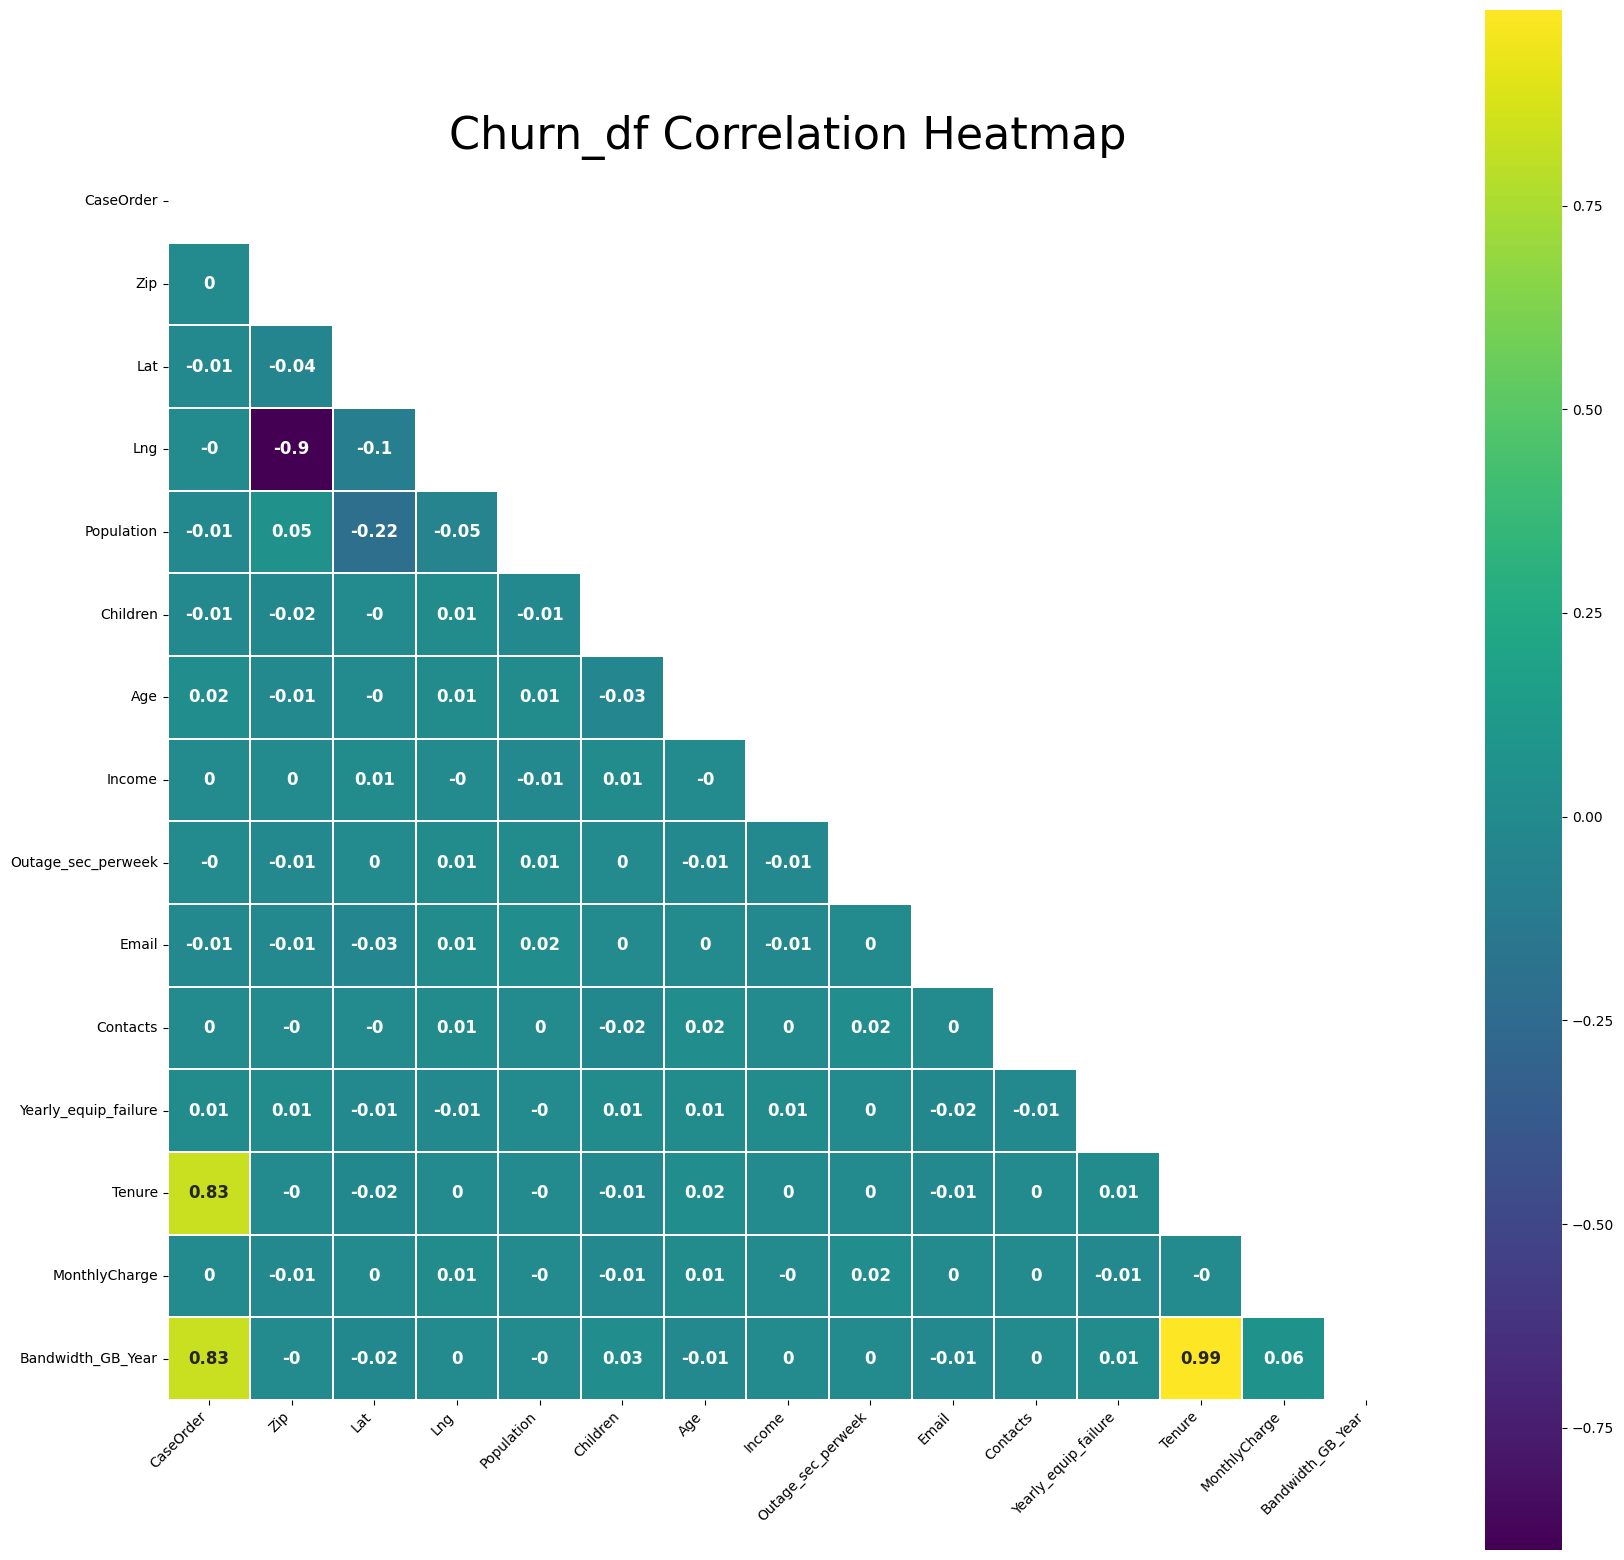

In [20]:
#Analysing the Correlation  /Relationship analysis
Continous_columns = Churn_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
Cor_data = Churn_df[Continous_columns]

def Generate_heatmap_graph(corr, chart_title, mask_uppertri=False):
    """ Based on features, generate a correlation matrix """
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = mask_uppertri
    fig, ax = plt.subplots(figsize=(20, 20))
    sns.heatmap(corr,
                mask=mask,
                square=True,
                annot=True,
                annot_kws={'size': 12, 'rotation': 0, 'weight': 'bold'},
                cmap=plt.get_cmap('viridis'),
                linewidths=.1,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
    plt.title(chart_title, fontsize=32)
    plt.show()
var_corr = round(Cor_data.corr(), 2)
Generate_heatmap_graph(var_corr, chart_title='Churn_df Correlation Heatmap', mask_uppertri=True)

In [21]:
#Dropping Columns that will not be used in the analysis 
Churn_df = Churn_df.drop (columns = ['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State', 'County', 'Zip', 'Lat', 'Lng','Job','TimeZone','Bandwidth_GB_Year'])

Distribution of Numerical data


<Figure size 1400x1000 with 0 Axes>

<Figure size 1000x2000 with 0 Axes>

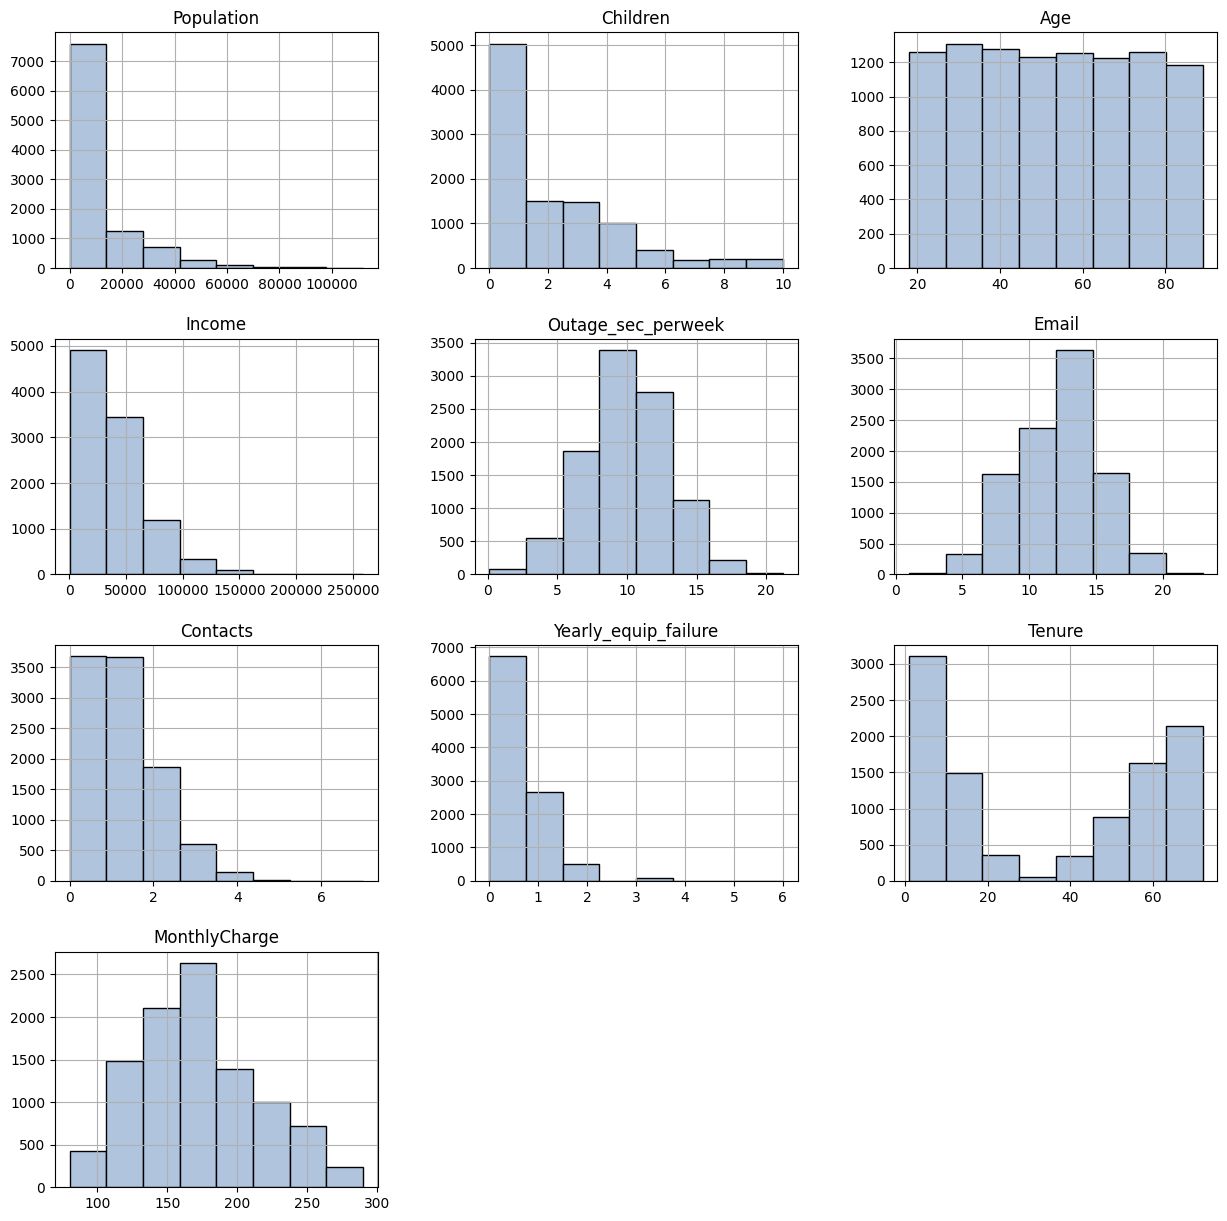

Distribution of Categorical data


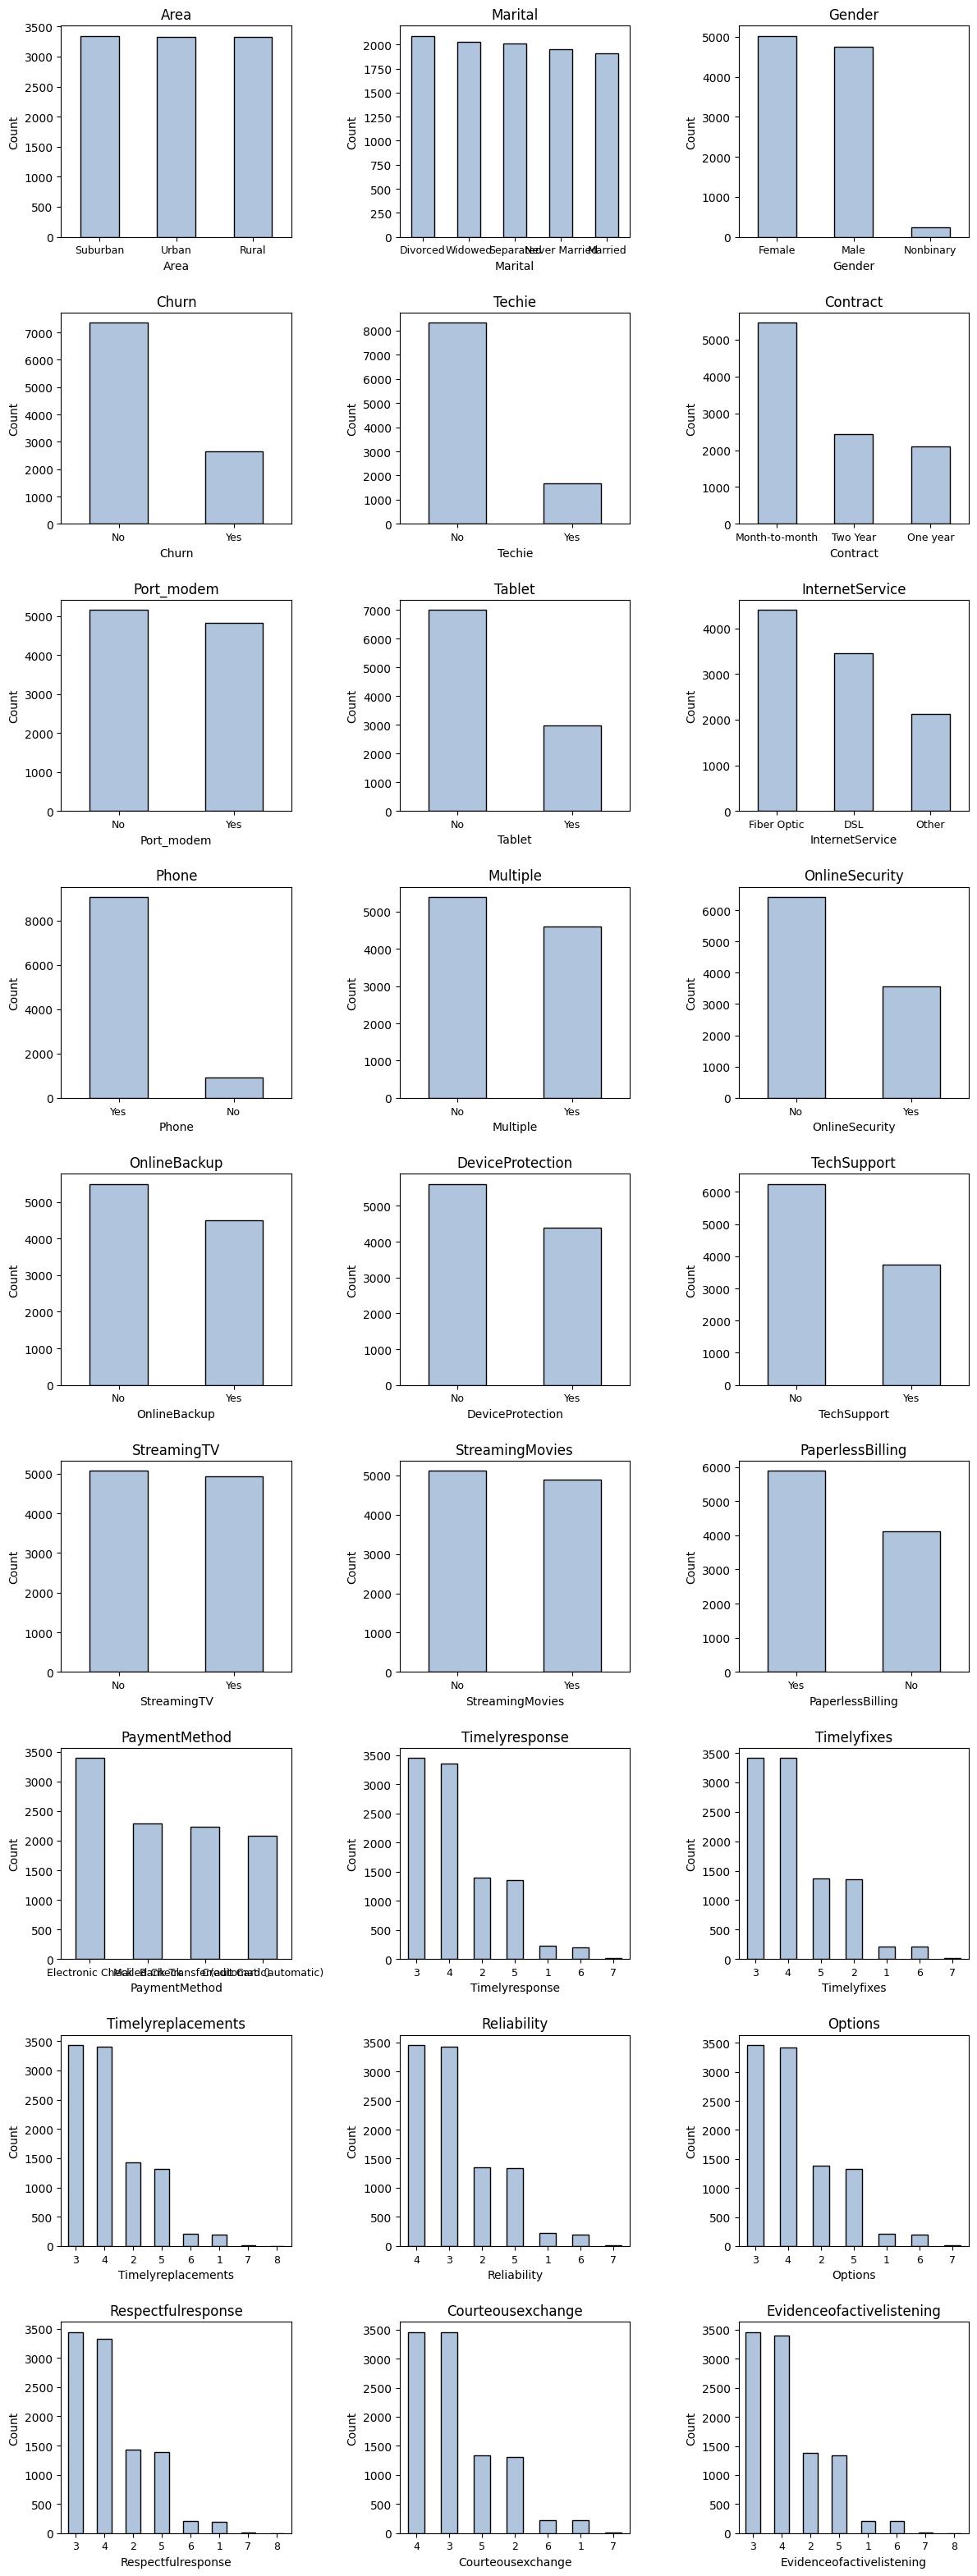

In [22]:
#Visualization of the data for Exploratory purposes
# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# Set the figure size for the plots
plt.figure(figsize=(14, 10))

#  Visualization of numeric features /Outlier detection
print('Distribution of Numerical data')

Continous_columns = Churn_df.select_dtypes(include=['float64','int64']).columns
fig = plt.figure(figsize=(10, 20))
ax = Churn_df[Continous_columns].hist(bins = 8, figsize=(15,15),color='lightsteelblue', edgecolor='black')
plt.title('Distibution of Numerical data')
fig.tight_layout(h_pad=5, w_pad=5)
plt.show()

# Visualization of Categorical data

print('Distribution of Categorical data')
# Distribution of Categorical data
Categorical_data = Churn_df.select_dtypes(exclude=['float64', 'int64']).columns

n_cols = 3 # Number of graphs per row
n_rows = -(-len(Categorical_data) // n_cols)  


fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows))

# Flatten axes for easy iteration if more than one row
axes = axes.flatten()

for i, col in enumerate(Categorical_data):
    Churn_df[col].value_counts().plot(kind='bar', ax=axes[i], color='lightsteelblue', edgecolor='black',stacked=True)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=0, labelsize=9)

# Remove any unused subplot axes
for j in range(len(Categorical_data), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=2, w_pad=2)
plt.show()


In [52]:
#PRINTING THE INITIAL VARIABLES THAT WILL BE USED FOR ANALYSIS
# Define target variable
target = 'Churn'

# Print information about the target variable
print(f"1. {target} \n The variable {target} is a categorical variable and will be used as a response (dependent) variable.The purpose of this analysis is to predict the customers who will Churn.")
#print(Churn_df[[target]].describe())

# List of columns that should be treated as categorical
categorical_columns = [
    'Timelyresponse', 'Timelyfixes', 'Timelyreplacements', 'Reliability',
    'Options', 'Respectfulresponse', 'Courteousexchange', 'Evidenceofactivelistening'
]

# Convert specified columns to 'object' dtype
for c in categorical_columns:
    Churn_df[c] = Churn_df[c].astype('object')

# Iterate through all columns (excluding the target)
counter = 2  # Start the counter from 2 because 1 is already used for the target
for idx, c in enumerate(Churn_df.columns):  # Iterate through all columns
    if c != target:  # Exclude the target column from analysis
        if Churn_df[c].dtype == "object":  # Check if the column is categorical (object type)
            print(f'\n{counter}. {c}  \n The variable {c} is categorical. It will be used as a predicting (independent) variable.')
            #print(f'   Unique values: {Churn_df[c].unique()}')
           # print(f'   Summary statistics:\n{Churn_df[c].describe().astype(str)}')  # Convert summary stats to string to display dtype as object
        else:  # If the column is numerical
            print(f'\n{counter}. {c}\n The variable {c} is numerical. It will be used as a predicting (independent) variable.')
           # print(f'   Summary statistics:\n{Churn_df[c].describe()}')
        counter += 1  # Increment the counter for the next variable

1. Churn 
 The variable Churn is a categorical variable and will be used as a response (dependent) variable.The purpose of this analysis is to predict the customers who will Churn.

2. Population
 The variable Population is numerical. It will be used as a predicting (independent) variable.

3. Area  
 The variable Area is categorical. It will be used as a predicting (independent) variable.

4. Children
 The variable Children is numerical. It will be used as a predicting (independent) variable.

5. Age
 The variable Age is numerical. It will be used as a predicting (independent) variable.

6. Income
 The variable Income is numerical. It will be used as a predicting (independent) variable.

7. Marital  
 The variable Marital is categorical. It will be used as a predicting (independent) variable.

8. Gender  
 The variable Gender is categorical. It will be used as a predicting (independent) variable.

9. Outage_sec_perweek
 The variable Outage_sec_perweek is numerical. It will be used as 

In [53]:
#Converting Categorical data to numerical data through dummy encoding (One Hot encoding)

categorical_columns = Churn_df.select_dtypes(include=['object']).columns.tolist()

# Separate binary and non-binary categorical columns
binary_columns = [col for col in categorical_columns if Churn_df[col].nunique() == 2]
non_binary_columns = [col for col in categorical_columns if Churn_df[col].nunique() > 2]

# Create dummy variables
Churn_df_encoded = pd.get_dummies(
    Churn_df, 
    columns=non_binary_columns,  # Include all dummies for non-binary variables
    dummy_na=False, 
    drop_first=False,  # Do not drop any dummy for non-binary
    dtype='int64'
)

# For binary columns, include only one dummy variable
Churn_df_encoded = pd.get_dummies(
    Churn_df_encoded, 
    columns=binary_columns, 
    dummy_na=False, 
    drop_first=True,  # Drop the first dummy for binary
    dtype='int64'
)

# Display the resulting dataframe
Churn_df_encoded.head()

,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Area_Rural,Area_Suburban,Area_Urban,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,Gender_Female,Gender_Male,Gender_Nonbinary,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,InternetService_Other,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,Timelyresponse_1,Timelyresponse_2,Timelyresponse_3,Timelyresponse_4,Timelyresponse_5,Timelyresponse_6,Timelyresponse_7,Timelyfixes_1,Timelyfixes_2,Timelyfixes_3,Timelyfixes_4,Timelyfixes_5,Timelyfixes_6,Timelyfixes_7,Timelyreplacements_1,Timelyreplacements_2,Timelyreplacements_3,Timelyreplacements_4,Timelyreplacements_5,Timelyreplacements_6,Timelyreplacements_7,Timelyreplacements_8,Reliability_1,Reliability_2,Reliability_3,Reliability_4,Reliability_5,Reliability_6,Reliability_7,Options_1,Options_2,Options_3,Options_4,Options_5,Options_6,Options_7,Respectfulresponse_1,Respectfulresponse_2,Respectfulresponse_3,Respectfulresponse_4,Respectfulresponse_5,Respectfulresponse_6,Respectfulresponse_7,Respectfulresponse_8,Courteousexchange_1,Courteousexchange_2,Courteousexchange_3,Courteousexchange_4,Courteousexchange_5,Courteousexchange_6,Courteousexchange_7,Evidenceofactivelistening_1,Evidenceofactivelistening_2,Evidenceofactivelistening_3,Evidenceofactivelistening_4,Evidenceofactivelistening_5,Evidenceofactivelistening_6,Evidenceofactivelistening_7,Evidenceofactivelistening_8,Churn_Yes,Techie_Yes,Port_modem_Yes,Tablet_Yes,Phone_Yes,Multiple_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes
0,38,0,68,28561.99,7.978323,10,0,1,6.795513,172.455519,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,1,1,0,0,0,1,1
1,10446,1,27,21704.77,11.699080,12,0,1,1.156681,242.632554,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,1,1,1,0,0,0,1,1,1
2,3735,4,50,9609.57,10.752800,9,0,1,15.754144,159.947583,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,1,1
3,13863,1,48,18925.23,14.913540,15,2,0,17.087227,119.956840,0,1,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,1
4,11352,0,83,40074.19,8.147417,16,2,1,1.670972,149.948316,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0


In [54]:
# 4. Explore the data – create numerical summaries, visualizations, etc.

In [55]:
Churn_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 103 entries, Population to PaperlessBilling_Yes
dtypes: float64(4), int64(99)
memory usage: 7.9 MB


In [56]:

Corelation = round(Churn_df_encoded.corr(),4)
Correlation_df =pd.DataFrame(Corelation)
Correlation_df.head(60)

# Identify highly correlated features (correlation > 0.9)
highly_correlated_features = set()
for i in range(len(Correlation_df.columns)):
    for j in range(i):
        if abs(Correlation_df.iloc[i, j]) > 0.9:
            colname = Correlation_df.columns[i]
            highly_correlated_features.add(colname)
print(highly_correlated_features)
# Drop the highly correlated features from the dataset
Churn_df_encoded = Churn_df_encoded.drop(columns=highly_correlated_features)

{'Gender_Male'}


In [57]:
# 5. Standardization (includes scaling, normalization, data types, etc., as applicable)

In [58]:
# Separate the X variables (explanatory) from the Y variable (response) into different dataframes
df_X = Churn_df_encoded.drop(["Churn_Yes"], axis=1).copy()
df_y = Churn_df_encoded["Churn_Yes"].copy()

In [59]:
# Standardize the X variables (explanatory) to put all on the same scale for KNN to measure distance
df_X = pd.DataFrame(preprocessing.MinMaxScaler().fit_transform(df_X), columns=df_X.columns)
df_X.head(20)

,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Area_Rural,Area_Suburban,Area_Urban,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,Gender_Female,Gender_Nonbinary,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,InternetService_Other,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,Timelyresponse_1,Timelyresponse_2,Timelyresponse_3,Timelyresponse_4,Timelyresponse_5,Timelyresponse_6,Timelyresponse_7,Timelyfixes_1,Timelyfixes_2,Timelyfixes_3,Timelyfixes_4,Timelyfixes_5,Timelyfixes_6,Timelyfixes_7,Timelyreplacements_1,Timelyreplacements_2,Timelyreplacements_3,Timelyreplacements_4,Timelyreplacements_5,Timelyreplacements_6,Timelyreplacements_7,Timelyreplacements_8,Reliability_1,Reliability_2,Reliability_3,Reliability_4,Reliability_5,Reliability_6,Reliability_7,Options_1,Options_2,Options_3,Options_4,Options_5,Options_6,Options_7,Respectfulresponse_1,Respectfulresponse_2,Respectfulresponse_3,Respectfulresponse_4,Respectfulresponse_5,Respectfulresponse_6,Respectfulresponse_7,Respectfulresponse_8,Courteousexchange_1,Courteousexchange_2,Courteousexchange_3,Courteousexchange_4,Courteousexchange_5,Courteousexchange_6,Courteousexchange_7,Evidenceofactivelistening_1,Evidenceofactivelistening_2,Evidenceofactivelistening_3,Evidenceofactivelistening_4,Evidenceofactivelistening_5,Evidenceofactivelistening_6,Evidenceofactivelistening_7,Evidenceofactivelistening_8,Techie_Yes,Port_modem_Yes,Tablet_Yes,Phone_Yes,Multiple_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes
0,0.000340,0.0,0.704225,0.109120,0.373260,0.409091,0.000000,0.166667,0.081624,0.439985,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
1,0.093393,0.1,0.126761,0.082599,0.549537,0.500000,0.000000,0.166667,0.002203,0.773872,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.033393,0.4,0.450704,0.035818,0.504705,0.363636,0.000000,0.166667,0.207804,0.380474,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.123943,0.1,0.422535,0.071848,0.701827,0.636364,0.285714,0.000000,0.226580,0.190207,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.101493,0.0,0.915493,0.153646,0.381271,0.681818,0.285714,0.166667,0.009447,0.332900,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0

In [60]:
df_y.head(20)

0     0
1     1
2     0
3     0
4     1
5     0
6     1
7     1
8     0
9     0
10    0
11    0
12    0
13    0
14    1
15    1
16    1
17    1
18    0
19    1
Name: Churn_Yes, dtype: int64

In [61]:
#  6. Feature Selection – select the variables you need for your analysis.

In [62]:
# Use SelectKBest to determine the best features to include in the model from the  features we're starting with
#Selecting features with a p_value <0.05. Indicate strong evidence against the null hypothesis, 
#suggesting that the observed result is unlikely to occur by chance.
feat_select = SelectKBest(f_classif, k='all')
feat_select.fit_transform(df_X, df_y)
feat_pvals = pd.DataFrame({'Feature' : df_X.columns, 'p_value' : feat_select.pvalues_}).sort_values('p_value')
Selected_Features=feat_pvals[feat_pvals['p_value'] < 0.05]


#print(Selected_Features[['Feature','p_value']])

Selected_Features = Selected_Features.copy()
Selected_Features['p_value_rounded'] = Selected_Features['p_value'].round(10)
pd.set_option('display.float_format', '{:.10f}'.format)
pd.set_option('display.max_columns', None)
print(Selected_Features[['Feature', 'p_value_rounded']])
pd.reset_option('display.float_format')

                           Feature  p_value_rounded
8                           Tenure     0.0000000000
9                    MonthlyCharge     0.0000000000
99             StreamingMovies_Yes     0.0000000000
20         Contract_Month-to-month     0.0000000000
98                 StreamingTV_Yes     0.0000000000
22               Contract_Two Year     0.0000000000
21               Contract_One year     0.0000000000
93                    Multiple_Yes     0.0000000000
23             InternetService_DSL     0.0000000000
89                      Techie_Yes     0.0000000000
24     InternetService_Fiber Optic     0.0000000049
96            DeviceProtection_Yes     0.0000000158
95                OnlineBackup_Yes     0.0000004339
25           InternetService_Other     0.0001599912
28  PaymentMethod_Electronic Check     0.0027744607
18                   Gender_Female     0.0068876225
92                       Phone_Yes     0.0085439734
77             Courteousexchange_4     0.0326455463


In [63]:
#  7. Export the Cleaned Data

In [64]:
columns = Selected_Features['Feature'].values.tolist()
# Recombine df_X (feature set) and df_y (response variable) to save the whole thing in one dataframe
Churn_Cleaned_df = df_X[columns].copy()
#Churn_Cleaned_df.insert(22, column="Churn_Yes", value=df_y.reset_index(drop=True))
# Save dataframe to CSV, ignore index (if included, this will create an additional unnecessary column)
Churn_Cleaned_df['Churn_Yes'] = df_y.reset_index(drop=True)
Churn_Cleaned_df.to_csv(OutputfilePath, index=False)

In [65]:

print('The Cleaned Data')
print(f'Churn_Cleaned_df.shape: {Churn_Cleaned_df.shape}')
Churn_Cleaned_df.info()

The Cleaned Data
Churn_Cleaned_df.shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tenure                          10000 non-null  float64
 1   MonthlyCharge                   10000 non-null  float64
 2   StreamingMovies_Yes             10000 non-null  float64
 3   Contract_Month-to-month         10000 non-null  float64
 4   StreamingTV_Yes                 10000 non-null  float64
 5   Contract_Two Year               10000 non-null  float64
 6   Contract_One year               10000 non-null  float64
 7   Multiple_Yes                    10000 non-null  float64
 8   InternetService_DSL             10000 non-null  float64
 9   Techie_Yes                      10000 non-null  float64
 10  InternetService_Fiber Optic     10000 non-null  float64
 11  DeviceProtection_Yes            10000 non

In [66]:
# 8. Split the Data – split the cleaned data.

In [67]:
# Set X and y (standard sklearn variables) to equal the selected X features and the y response of interest

X = Churn_Cleaned_df.drop(["Churn_Yes"], axis=1).copy()
y = Churn_Cleaned_df["Churn_Yes"].copy()


In [68]:

print('Before Data Split')
print(f'X.shape: {X.shape}')
print(f'y.shape: {y.shape}')


Before Data Split
X.shape: (10000, 18)
y.shape: (10000,)


In [69]:
# Split the data into train and test sets, 80% train, 20% test, use stratify to maintain proportions across split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, test_size=0.2, random_state = 42, stratify = y)

In [70]:

print("After data Split")
print(f'X_train.shape: {X_train.shape}')
print(f'X_test.shape: {X_test.shape}')
print(f'y_train.shape: {y_train.shape}')
print(f'y_test.shape: {y_test.shape}')


After data Split
X_train.shape: (8000, 18)
X_test.shape: (2000, 18)
y_train.shape: (8000,)
y_test.shape: (2000,)


In [71]:
# Save each of the split data for Xtrain,Xtest,ytrain,y,test
X_train.to_csv(XtrainOutputfilePath, index=False)
X_test.to_csv(XtestOutputfilePath, index=False)
y_train.to_csv(ytrainOutputfilePath, index=False)
y_test.to_csv(ytestOutputfilePath, index=False)

In [72]:
#  9. Create or initialize the model – call the KNN Classifier

In [73]:
knn = KNeighborsClassifier()

In [74]:
# 10. Train and fit the model.

In [75]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [76]:
#  11. Evaluate the model for Accuracy and check the error metrics (includes accuracy, 
#precision, recall, F1-score, ROC-AUC)

Best Parameters: {'n_neighbors': 5, 'weights': 'uniform'}
Best F1-Score: 0.69
 
Initial Model Evaluation Metrics:
Initial Accuracy: 0.85
Initial Precision: 0.77
Initial Recall: 0.63
Initial F1 Score: 0.69
Initial ROC-AUC: 0.88
 
Initial Model Accuracy Scores:
The training accuracy of this KNN classification Initial model is 0.8945
The testing accuracy of this KNN classification Initial model is 0.8525
 
KNN Initial Model Classification Report:
Classification_ Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      1470
           1       0.77      0.63      0.69       530

    accuracy                           0.85      2000
   macro avg       0.82      0.78      0.80      2000
weighted avg       0.85      0.85      0.85      2000

 
Initial Confusion Matrix:


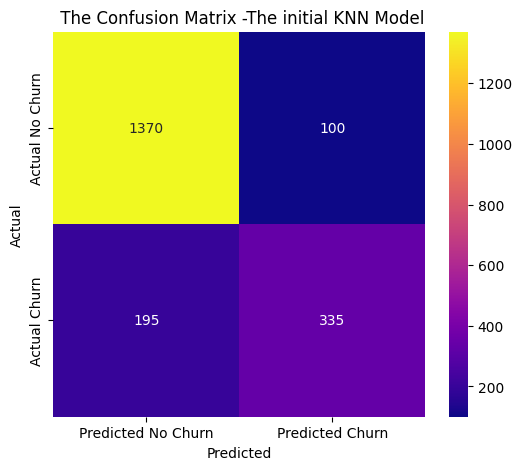

 
Initial ROC Curve:


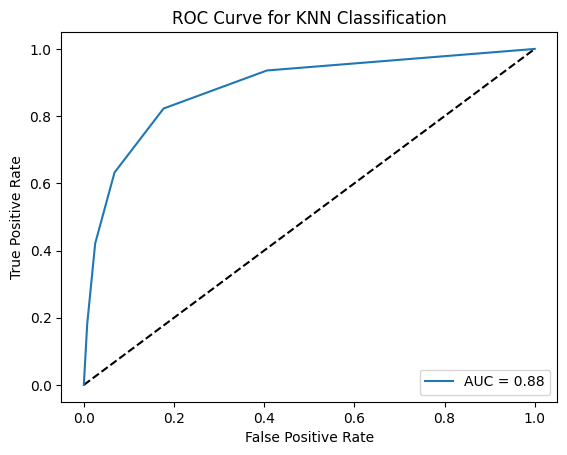

In [77]:

 #predictions
y_pred = knn.predict(X_test)
y_proba =knn.predict_proba(X_test)[:,1]

# Evaluate model
#Accuracy
accuracy = accuracy_score(y_test, y_pred)


# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

best_params = {'n_neighbors': knn.n_neighbors, 'weights': knn.weights}
best_score = f1 

print("Best Parameters:", best_params)
print("Best F1-Score:", round(best_score, 2))
print(" ")
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("\033[1m\033[4m\033[38;2;0;0;0mInitial Model Evaluation Metrics:\033[0m")

print(f'Initial Accuracy: {round(accuracy,2)}')
print(f"Initial Precision: {round(precision,2)}")
print(f"Initial Recall: {round(recall,2)}")
print(f"Initial F1 Score: {round(f1,2)}")
print(f"Initial ROC-AUC: {roc_auc:.2f}")
print(" ")
# Print training and testing accuracy
print("\033[1m\033[4m\033[38;2;0;0;0mInitial Model Accuracy Scores:\033[0m")
print(f"The training accuracy of this KNN classification Initial model is {knn.score(X_train, y_train)}")
print(f"The testing accuracy of this KNN classification Initial model is {knn.score(X_test, y_test)}")

print(" ")
print("\033[1m\033[4m\033[38;2;0;0;0mKNN Initial Model Classification Report:\033[0m")
print("Classification_ Report:\n", classification_report(y_test, y_pred))

#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
initialMatrix=confusion_matrix(y_test, y_pred)
print(" ")
# Plot confusion matrix using seaborn heatmap
print("\033[1m\033[4m\033[38;2;0;0;0mInitial Confusion Matrix:\033[0m")
plt.figure(figsize=(6, 5))
sns.heatmap(initialMatrix, annot=True, fmt="d", cmap="plasma", xticklabels=["Predicted No Churn", "Predicted Churn"], yticklabels=["Actual No Churn", "Actual Churn"])
plt.title(" The Confusion Matrix -The initial KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(" ")
# Plot the ROC curve
print("\033[1m\033[4m\033[38;2;0;0;0mInitial ROC Curve:\033[0m")
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN Classification')
plt.legend(loc="lower right")
plt.show()

In [78]:
#  12. Optimize the model (includes hyperparameter tuning or cross-validation).

In [79]:
# Determine what is the best number of neighbors to use for KNN classification, from values of k = 1 to k = 50. 
#Determine the weighing strategy of the neighbor whether its is uniform where all neighbors contribute equally or
#it is distance where neighbors are weighed based on the distance and search for the best metric to calculate the distance. 

param_grid = {
    "n_neighbors": np.arange(1, 50),
   # "weights": ["uniform", "distance"],
   # "metric": ["euclidean", "manhattan"]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,  # fold cross-validation
    scoring="f1",  # Use F1-Score for evaluation
    verbose=1
)

# Perform grid search
grid_search.fit(X_train, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best F1-Score:", round(best_score,2))

# Use the best model
best_knn = grid_search.best_estimator_

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Best Parameters: {'n_neighbors': 11}
Best F1-Score: 0.68


Final Model Evaluation Metrics:
Final Accuracy: 0.86
Final Precision: 0.81
Final Recall: 0.63
Final F1-Score: 0.71
Final ROC-AUC: 0.91
Final Model Accuracy Scores:
The training accuracy of this KNN classification Final model is 0.8785
The testing accuracy of this KNN classification Final model is 0.863
KNN final Model Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1470
           1       0.81      0.63      0.71       530

    accuracy                           0.86      2000
   macro avg       0.84      0.79      0.81      2000
weighted avg       0.86      0.86      0.86      2000

Final Confusion Matrix:


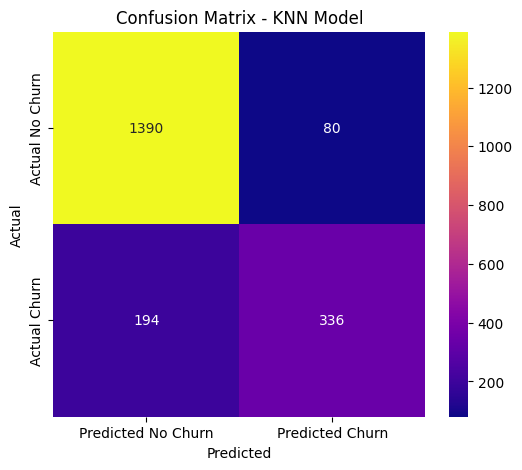

Final ROC Curve:


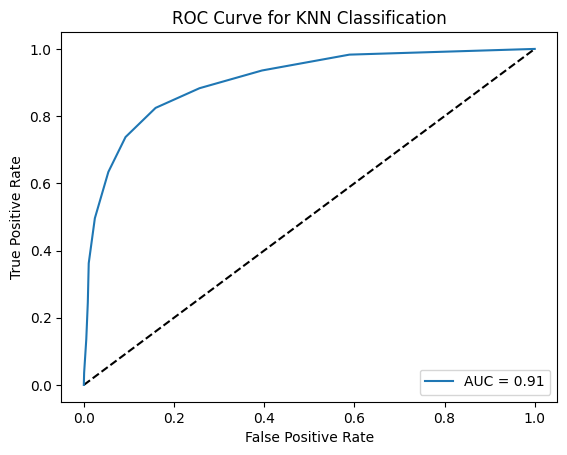

In [80]:
# Forecast or Predict using the optimized KNN model
final_predictions = best_knn.predict(X_test)
final_proba = best_knn.predict_proba(X_test)[:, 1]

# Evaluate the final model
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)
final_roc_auc = roc_auc_score(y_test, final_proba)

# Print final metrics
print("\033[1m\033[4m\033[38;2;0;0;0mFinal Model Evaluation Metrics:\033[0m")
print(f"Final Accuracy: {final_accuracy:.2f}")
print(f"Final Precision: {final_precision:.2f}")
print(f"Final Recall: {final_recall:.2f}")
print(f"Final F1-Score: {final_f1:.2f}")
print(f"Final ROC-AUC: {final_roc_auc:.2f}")

# Print training and testing accuracy
print("\033[1m\033[4m\033[38;2;0;0;0mFinal Model Accuracy Scores:\033[0m")
print(f"The training accuracy of this KNN classification Final model is {best_knn.score(X_train, y_train)}")
print(f"The testing accuracy of this KNN classification Final model is {best_knn.score(X_test, y_test)}")


# Print the classification report
print("\033[1m\033[4m\033[38;2;0;0;0mKNN final Model Classification Report:\033[0m")
print(classification_report(y_test, final_predictions))

# Generate the confusion matrix
final_matrix = confusion_matrix(y_test, final_predictions)

# Plot confusion matrix using seaborn heatmap
print("\033[1m\033[4m\033[38;2;0;0;0mFinal Confusion Matrix:\033[0m")
plt.figure(figsize=(6, 5))
sns.heatmap(final_matrix, annot=True, fmt="d", cmap="plasma",
            xticklabels=["Predicted No Churn", "Predicted Churn"],
            yticklabels=["Actual No Churn", "Actual Churn"])
plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Plot the ROC curve
print("\033[1m\033[4m\033[38;2;0;0;0mFinal ROC Curve:\033[0m")
fpr, tpr, thresholds = roc_curve(y_test, final_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label=f"AUC = {final_roc_auc:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN Classification')
plt.legend(loc="lower right")
plt.show()


